In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv


# Step 1 - Problem Definition

### Problem Definition
This project aims to predict whether a smartphone user is addicted or not based on their daily usage behavioral patterns — including screen time, social media usage, gaming hours, and sleep duration.

The model output is a binary classification: 1 = addicted, 0 = not addicted (target: addicted_label).

### Motivation
Smartphone addiction is a growing concern in the digital age. Early detection can benefit:

* Digital health researchers studying behavioral patterns
* Parents monitoring their children's smartphone usage
* Mental health practitioners designing intervention programs

Dataset
7,500 records · 16 features · No missing values in target column · Class distribution: 70.8% addicted / 29.2% not addicted (imbalanced)

### Evaluation Metrics
Since the dataset is imbalanced, accuracy alone is not sufficient. Primary metric: ROC-AUC. Secondary: Recall, F1-Score, and Confusion Matrix.

# Step 2 - Exploratory Data Analysis

In [2]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler


In [3]:
df = pd.read_csv("/kaggle/input/datasets/jayjoshi37/smartphone-usage-and-addiction-prediction/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.head(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


In [4]:
df.shape

(7500, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [6]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [7]:
# checking missing value
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [8]:
# Calculate the percentage addicted
count = df['addicted_label'].value_counts()
pct = df['addicted_label'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Total' : count,
    'Percentage %' : pct.round(1)
})

summary.index = ['Addicted (0)', 'Not-Addicted (1)']
print(summary)

                  Total  Percentage %
Addicted (0)       5308          70.8
Not-Addicted (1)   2192          29.2


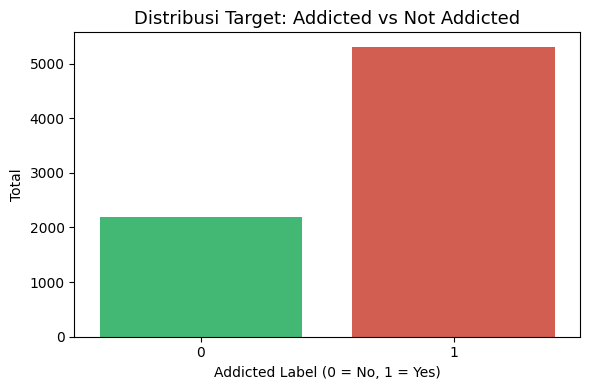

In [9]:
# visualization with bar plot
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='addicted_label',
    hue='addicted_label',
    palette=['#2ecc71', '#e74c3c'],
    legend=False
)
plt.title('Distribusi Target: Addicted vs Not Addicted', fontsize=13)
plt.xlabel('Addicted Label (0 = No, 1 = Yes)')
plt.ylabel('Total')

plt.tight_layout()
plt.show()

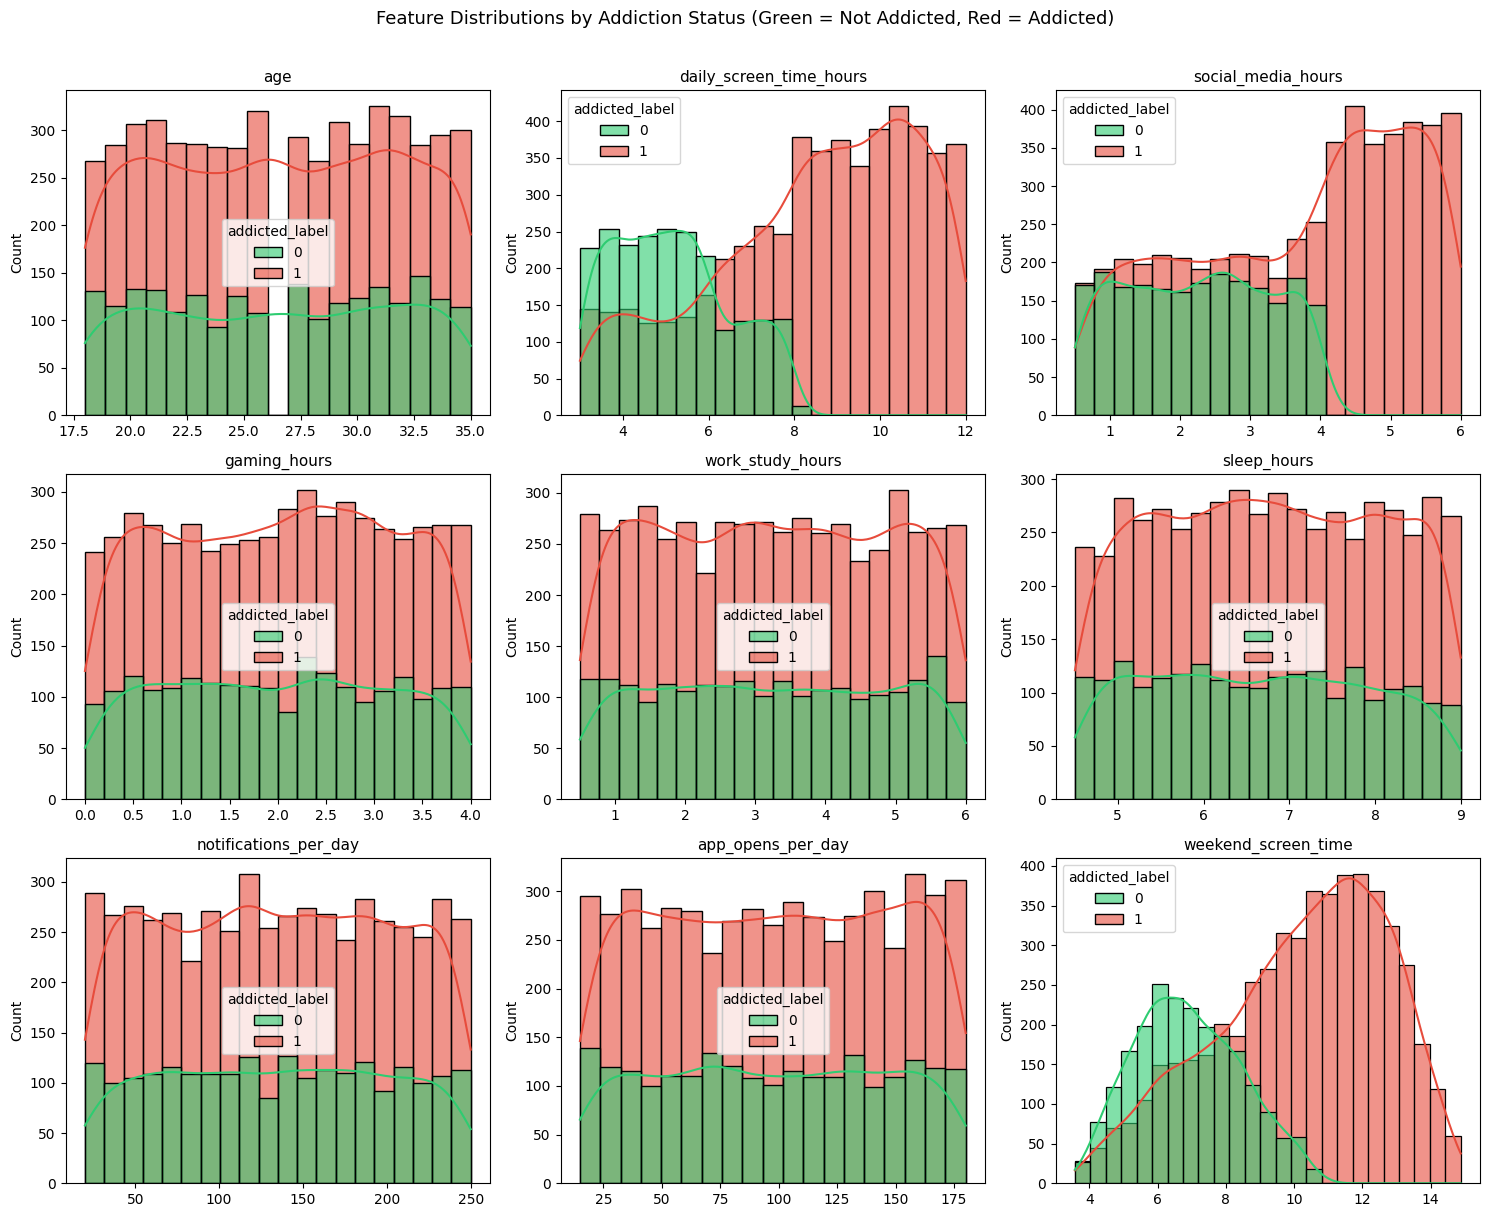

In [10]:
# List of 9 numerical features to visualize
num_cols = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

# Create a 3x3 canvas — 3 rows, 3 columns, 9 subplots total
fig, axes = plt.subplots(3,3, figsize=(15,12))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(
        data=df,
        x = col,
        hue = 'addicted_label',
        kde = True,
        palette=['#2ecc71', '#e74c3c'],
        alpha=0.6,            
        ax=ax              
    )
    ax.set_title(col, fontsize=11)  
    ax.set_xlabel('')              

plt.suptitle(
    'Feature Distributions by Addiction Status (Green = Not Addicted, Red = Addicted)',
    fontsize=13, y=1.01
)   

plt.tight_layout()
plt.show()

"The most separating features between addicted and non-addicted users are daily_screen_time_hours, weekend_screen_time, and social_media_hours. Features such as age, gaming hours, sleep hours, and notifications show almost identical distributions between both classes, suggesting they may have low predictive power."

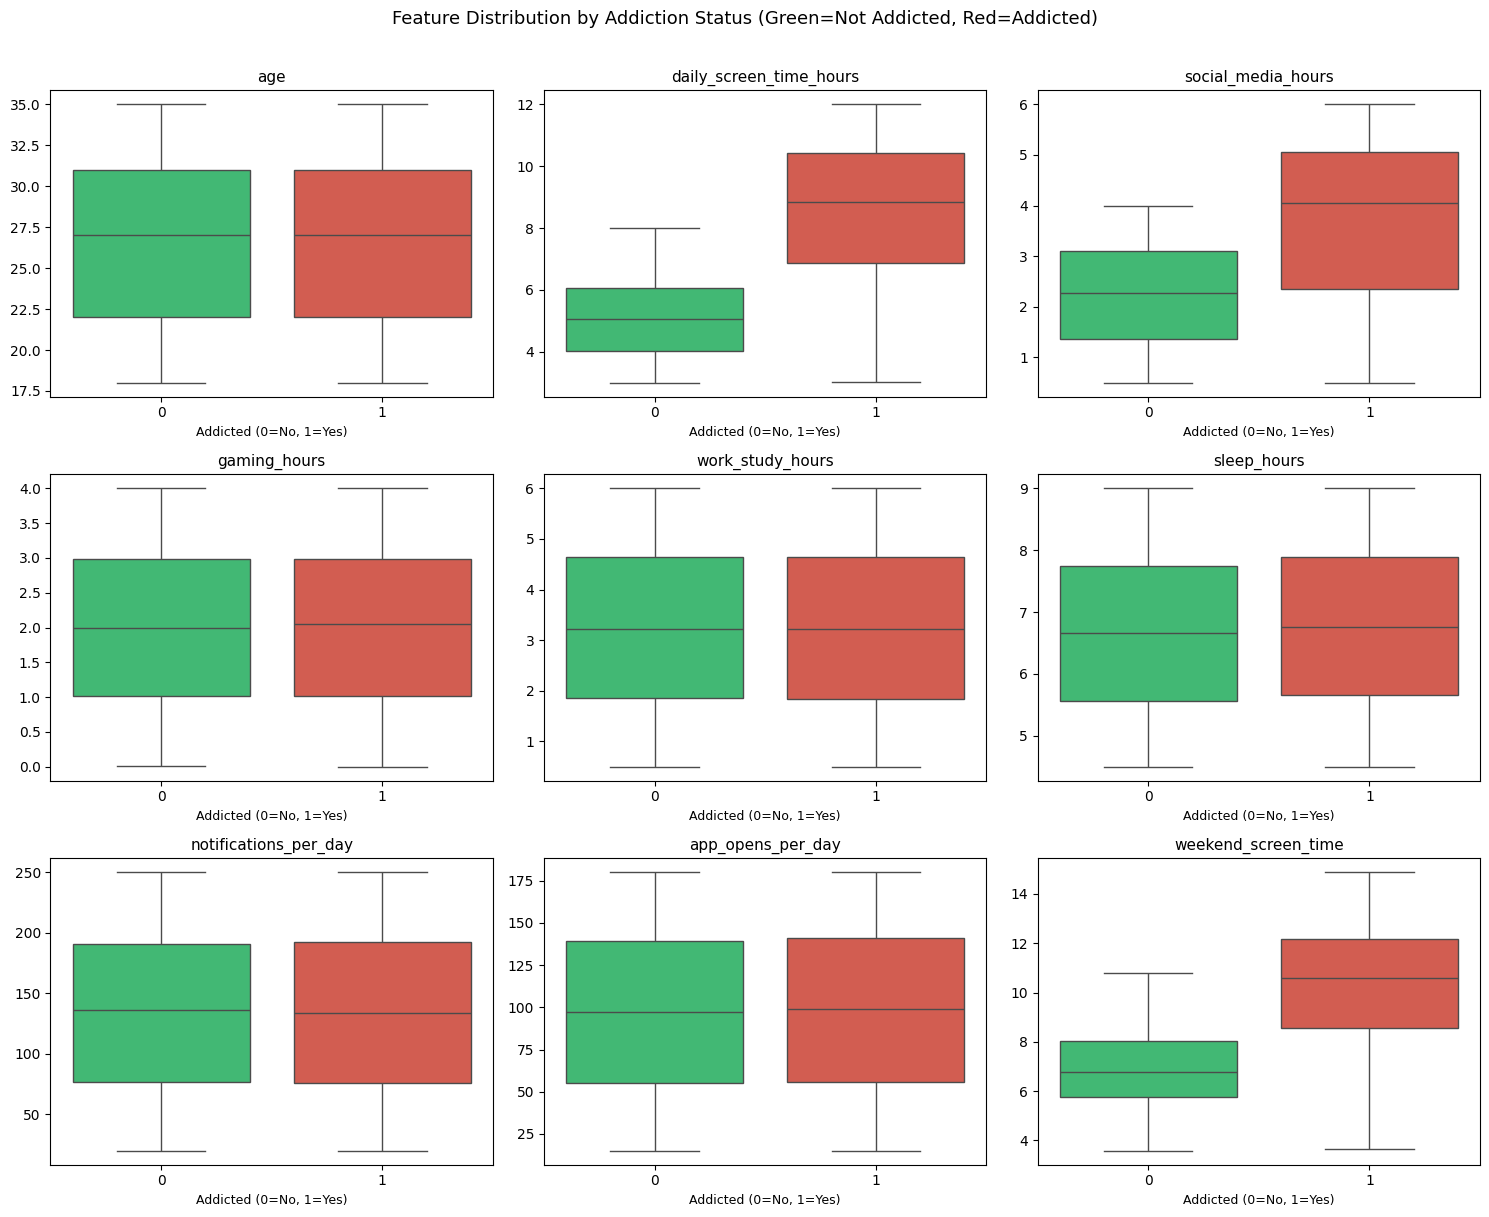

In [11]:
# List of numerical features to compare
num_cols = [
    'age', 'daily_screen_time_hours', 'social_media_hours',
    'gaming_hours', 'work_study_hours', 'sleep_hours',
    'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time'
]

# Create 3x3 canvas — same structure as histogram
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(
        data=df,
        x='addicted_label',   
        y=col,               
        hue='addicted_label',
        palette=['#2ecc71', '#e74c3c'],
        legend=False,
        ax=ax
    )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Addicted (0=No, 1=Yes)', fontsize=9)
    ax.set_ylabel('')

plt.suptitle(
    'Feature Distribution by Addiction Status (Green=Not Addicted, Red=Addicted)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

## EDA Key Insights

**Insight 1 — Imbalanced Dataset**
The target variable is imbalanced: 70.8% of users are addicted (1) 
and only 29.2% are not addicted (0). This means accuracy alone is 
not a reliable metric — we will use ROC-AUC and Recall as our 
primary evaluation metrics.

**Insight 2 — Strongest Predictors**
Features with the most visible separation between addicted and 
non-addicted users are daily_screen_time_hours (r=+0.577), 
weekend_screen_time (r=+0.555), and social_media_hours (r=+0.414). 
Users who are addicted consistently show higher values in these 
features compared to non-addicted users.

**Insight 3 — Weak Predictors**
Features such as age, gaming_hours, sleep_hours, 
notifications_per_day, and app_opens_per_day show almost identical 
distributions between both classes (correlation ≈ 0). These features 
are unlikely to contribute significantly to the model's prediction.

# Step 3 - Preprocessing


In [12]:
# Step 1: Drop columns we don't need
cols_to_drop = ['transaction_id', 'user_id', 'addiction_level']
df_clean = df.drop(columns=cols_to_drop)

# Step 2: Ordinal Encoding — stress_level (Low=0, Medium=1, High=2)
stress_map = {'Low':0, 'Medium':1, 'High':2}
df_clean['stress_level'] = df_clean['stress_level'].map(stress_map)

# Step 3: One-Hot Encoding — gender & academic_work_impact
df_clean = pd.get_dummies(df_clean, columns=['gender', 'academic_work_impact'], drop_first=True)

# Step 4: Separate features and target
X = df_clean.drop(columns=['addicted_label'])
y = df_clean['addicted_label']

# Verify shapes
print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Columns after preprocessing: {X.columns.tolist()}")
df_clean.head(3)

Features shape : (7500, 13)
Target shape   : (7500,)
Columns after preprocessing: ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'gender_Male', 'gender_Other', 'academic_work_impact_Yes']


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,addicted_label,gender_Male,gender_Other,academic_work_impact_Yes
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,0,True,False,True
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,0,False,True,True
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,False,True,False


# Step 4 - Feature Selection


In [13]:
# Step 1: Pearson Correlation vs target
corr = X.corrwith(y).abs().sort_values(ascending=False)
print("=== Correlation vs Target ===")
print(corr.round(3))

# Step 2: Mutual Information
mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("\n=== Mutual Information Scores ===")
print(mi_scores.round(4))

=== Correlation vs Target ===
daily_screen_time_hours     0.577
weekend_screen_time         0.555
social_media_hours          0.414
sleep_hours                 0.035
gender_Male                 0.023
gender_Other                0.015
app_opens_per_day           0.011
gaming_hours                0.008
stress_level                0.008
age                         0.004
work_study_hours            0.001
notifications_per_day       0.001
academic_work_impact_Yes    0.000
dtype: float64

=== Mutual Information Scores ===
daily_screen_time_hours     0.2422
weekend_screen_time         0.2102
social_media_hours          0.1630
stress_level                0.0081
work_study_hours            0.0062
age                         0.0043
academic_work_impact_Yes    0.0031
sleep_hours                 0.0008
notifications_per_day       0.0001
gaming_hours                0.0000
app_opens_per_day           0.0000
gender_Male                 0.0000
gender_Other                0.0000
dtype: float64


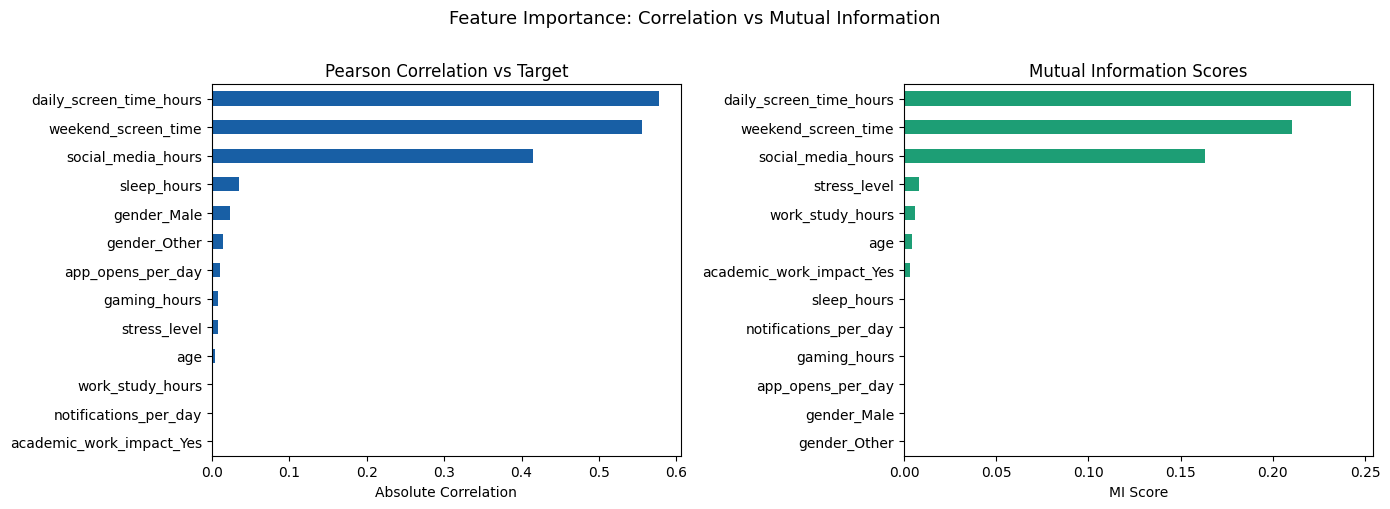

In [14]:
# Compare both methods side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation bar chart
corr.plot(kind='barh', ax=axes[0], color='#185FA5')
axes[0].set_title('Pearson Correlation vs Target', fontsize=12)
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Mutual Information bar chart
mi_scores.plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].set_title('Mutual Information Scores', fontsize=12)
axes[1].set_xlabel('MI Score')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance: Correlation vs Mutual Information',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Select features that appear important in BOTH methods
# Keep features with MI score above threshold
threshold = 0.01
selected_features = mi_scores[mi_scores > threshold].index.tolist()

print(f"Selected features ({len(selected_features)}): {selected_features}")

# Filter X to keep only selected features
X_selected = X[selected_features]
print(f"\nFinal X shape: {X_selected.shape}")

Selected features (3): ['daily_screen_time_hours', 'weekend_screen_time', 'social_media_hours']

Final X shape: (7500, 3)


# Step 5 - Model Training

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.3,
    stratify=y,        
    random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn %: {y_train.mean():.1%}")
print(f"Test  churn %: {y_test.mean():.1%}")

Train: (5250, 3) | Test: (2250, 3)
Train churn %: 70.8%
Test  churn %: 70.8%


The dataset is split into **70% training** and **30% test** set.
Since the dataset is imbalanced (70.8% addicted), we use `stratify=y` 
to ensure both sets maintain the same class proportion.

| Set | Rows | Addicted % |
|-----|------|------------|
| Train | 5,250 | 70.8% |
| Test  | 2,250 | 70.8% |

> The identical addiction rate in both sets confirms that 
> stratified sampling worked correctly — the model will 
> learn from a representative distribution.

In [17]:
# Scaling — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn + apply
X_test_scaled  = scaler.transform(X_test)       # apply only — no leakage!

# Define 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss')
}

In [18]:
from sklearn.metrics import roc_auc_score, classification_report

results = {}  # store results for comparison

for name, model in models.items():

    # Logistic Regression uses scaled data, tree models don't need it
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc

    print(f"{'='*45}")
    print(f"Model : {name}")
    print(f"ROC-AUC : {auc:.4f}")
    print(classification_report(y_test, y_pred,
          target_names=['Not Addicted', 'Addicted']))

Model : Logistic Regression
ROC-AUC : 0.9536
              precision    recall  f1-score   support

Not Addicted       0.84      0.79      0.81       658
    Addicted       0.92      0.94      0.93      1592

    accuracy                           0.89      2250
   macro avg       0.88      0.86      0.87      2250
weighted avg       0.89      0.89      0.89      2250

Model : Random Forest
ROC-AUC : 0.9884
              precision    recall  f1-score   support

Not Addicted       0.87      0.89      0.88       658
    Addicted       0.95      0.95      0.95      1592

    accuracy                           0.93      2250
   macro avg       0.91      0.92      0.92      2250
weighted avg       0.93      0.93      0.93      2250

Model : XGBoost
ROC-AUC : 0.9878
              precision    recall  f1-score   support

Not Addicted       0.87      0.90      0.88       658
    Addicted       0.96      0.95      0.95      1592

    accuracy                           0.93      2250
   macro av

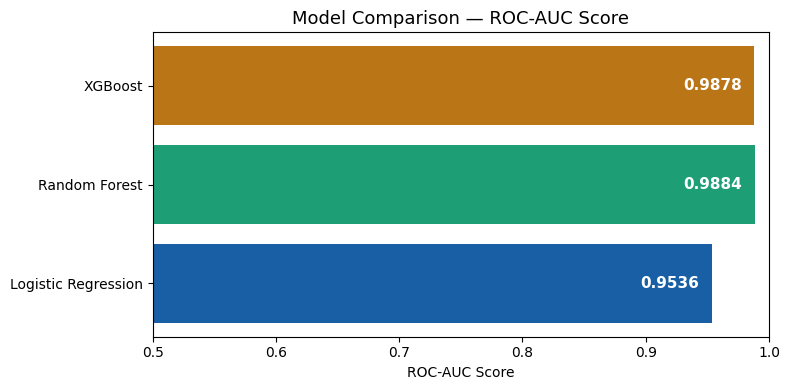


Best model: Random Forest (ROC-AUC: 0.9884)


In [19]:
# Bar chart comparison
plt.figure(figsize=(8, 4))
bars = plt.barh(
    list(results.keys()),
    list(results.values()),
    color=['#185FA5', '#1D9E75', '#BA7517']
)

# Add score labels on each bar
for bar, score in zip(bars, results.values()):
    plt.text(
        bar.get_width() - 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.4f}',
        ha='right', va='center',
        color='white', fontweight='bold', fontsize=11
    )

plt.title('Model Comparison — ROC-AUC Score', fontsize=13)
plt.xlabel('ROC-AUC Score')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

# Print winner
winner = max(results, key=results.get)
print(f"\nBest model: {winner} (ROC-AUC: {results[winner]:.4f})")

# Step 6 - Evaluation


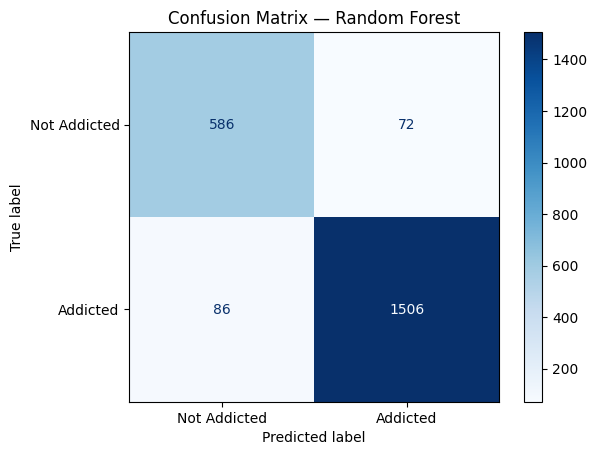

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

# Get best model from dictionary 
best_model = models['Random Forest']

# Predict using TEST features
y_pred_best = best_model.predict(X_test)

# Plot confusion matrix — actual vs predicted
ConfusionMatrixDisplay.from_predictions(
    y_test,        # actual values (the truth)
    y_pred_best,   # predicted values (model's answer)
    display_labels=['Not Addicted', 'Addicted'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Random Forest')
plt.show()

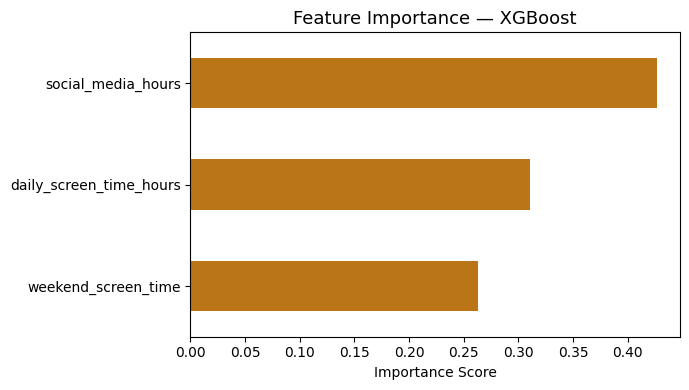

social_media_hours         0.426567
daily_screen_time_hours    0.310640
weekend_screen_time        0.262792
dtype: float64


In [21]:
# XGBoost has built-in feature importance
importance = pd.Series(
    best_model.feature_importances_,
    index=X_selected.columns
).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importance.plot(kind='barh', color='#BA7517')
plt.title('Feature Importance — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)

In [22]:
# Summary of all models
summary = pd.DataFrame({
    'Model'  : list(results.keys()),
    'ROC-AUC': [round(v, 4) for v in results.values()]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

summary['Rank'] = ['🥇', '🥈', '🥉']
print(summary.to_string(index=False))

              Model  ROC-AUC Rank
      Random Forest   0.9884    🥇
            XGBoost   0.9878    🥈
Logistic Regression   0.9536    🥉


### Key Findings

**Finding 1 — Screen time is the strongest predictor**
Only 3 features were needed to build a highly accurate model:
`daily_screen_time_hours`, `weekend_screen_time`, and 
`social_media_hours`. This confirms that addiction is primarily 
driven by total time spent on screen, not by specific activities 
like gaming or notifications.

**Finding 2 — Model performance**
All three models achieved ROC-AUC above 0.90, indicating strong 
ability to distinguish addicted from non-addicted users. Random 
Forest achieved the highest score with minimal overfitting.

**Finding 3 — False Negatives (model limitation)**
The model missed **86 addicted users** (False Negatives) — 
these are the most critical errors. In a real-world intervention 
system, these users would receive no help despite being addicted.
Future work could focus on optimizing the decision threshold to 
reduce FN at the cost of higher FP.

---

### Recommendations

- Users spending more than **8 hours/day** on screens should be 
  flagged for digital wellness intervention
- Weekend screen time is equally important as weekday — 
  monitoring both is essential
- A lower classification threshold (< 0.5) could reduce 
  False Negatives for high-stakes applications

---

### What I Learned
This project covers the full ML pipeline: EDA → Preprocessing → 
Feature Selection → Model Training → Evaluation. The most 
surprising finding was that just 3 features out of 13 were 
sufficient to achieve 90%+ ROC-AUC.